# Exploratory Data Analysis

- Dataset inspection
- Message length distribution
- Dialogue length distribution
- Same-user turn analysis
- Vocabulary exploration

i. Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')

print("Shape:", df.shape)
df.head()

Shape: (1038324, 6)


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


1. Message length distribution
- This helps justify the decision for MAX_LENGTH

count    1.038235e+06
mean     1.059930e+01
std      1.031706e+01
min      0.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.070000e+02
Name: msg_length, dtype: float64


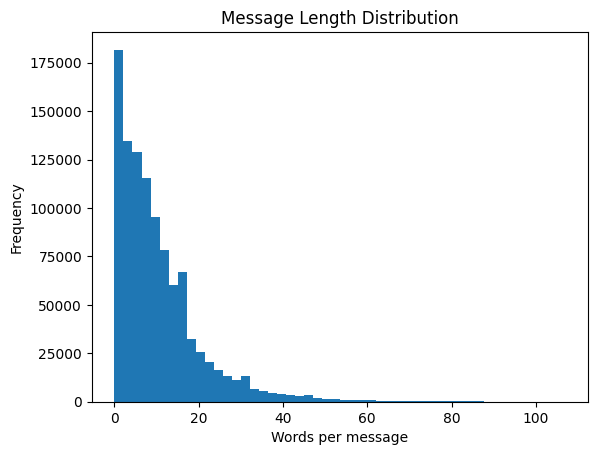

In [3]:
df = df.dropna(subset=['text'])

df['msg_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print(df['msg_length'].describe())

plt.hist(df['msg_length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Words per message")
plt.ylabel("Frequency")
plt.show()

2. Dialogue length distribution
- This supports our context window design

count    346108.000000
mean          2.999743
std           0.018384
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
dtype: float64


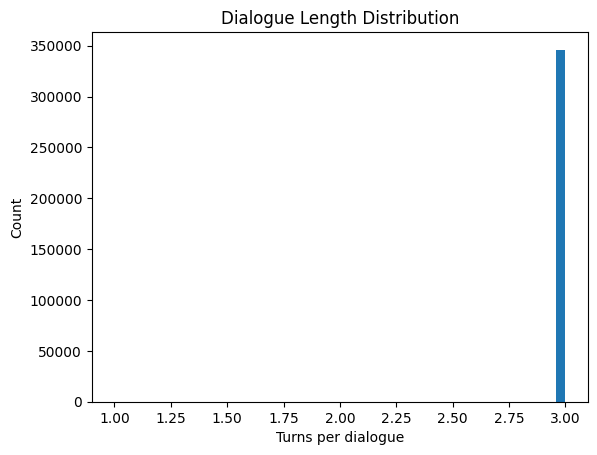

In [4]:
dialogue_lengths = df.groupby(['folder','dialogueID']).size()

print(dialogue_lengths.describe())

plt.hist(dialogue_lengths, bins=50)
plt.title("Dialogue Length Distribution")
plt.xlabel("Turns per dialogue")
plt.ylabel("Count")
plt.show()

3. Pair Quality Diagnostics
- How often does the same user appears in consecutive turns?
- This can indicate noisy pairing due to the presence of multi-user conversations.

In [5]:
same_user_pairs = 0
total_pairs = 0

grouped = df.groupby(['folder', 'dialogueID'])

for _, dialogue in grouped:
    dialogue = dialogue.reset_index(drop=True)

    for i in range(1, len(dialogue)):
        total_pairs += 1
        
        sender_prev = dialogue.loc[i-1, 'from']
        sender_curr = dialogue.loc[i, 'from']
        
        if sender_prev == sender_curr:
            same_user_pairs += 1

percentage = (same_user_pairs / total_pairs) * 100

print("Pair Quality Diagnostic")
print("----------------------")
print(f"Total consecutive turns: {total_pairs}")
print(f"Same-user turns: {same_user_pairs}")
print(f"Percentage same-user turns: {percentage:.2f}%")

Pair Quality Diagnostic
----------------------
Total consecutive turns: 692127
Same-user turns: 261225
Percentage same-user turns: 37.74%


4. Vocabulary Coverage Analysis
- How much of the text is still representable if we drop rare words?
- This helps justify the decision for MIN_TOKEN_FREQ

In [6]:
from collections import Counter

print("Vocabulary Coverage Analysis")
print("----------------------------")

counter = Counter()

for text in df['text'].dropna():
    tokens = text.lower().split()
    counter.update(tokens)

total_tokens = sum(counter.values())

for min_freq in [1,2,3,5,10]:
    kept_tokens = sum(c for w,c in counter.items() if c >= min_freq)
    vocab_size = sum(1 for w,c in counter.items() if c >= min_freq)

    print(f"min_freq={min_freq}")
    print(f"  vocab_size={vocab_size}")
    print(f"  coverage={(kept_tokens/total_tokens):.2%}")

Vocabulary Coverage Analysis
----------------------------
min_freq=1
  vocab_size=369203
  coverage=100.00%
min_freq=2
  vocab_size=125137
  coverage=97.78%
min_freq=3
  vocab_size=76708
  coverage=96.90%
min_freq=5
  vocab_size=48031
  coverage=96.02%
min_freq=10
  vocab_size=28233
  coverage=94.86%


5. GloVe Coverage Analysis
- How much of our dataset vocabulary appears in pretrained embeddings?
- This helps assess their suitability.

In [ ]:
import numpy as np

print("GloVe Coverage Analysis")
print("----------------------")

# Loading GloVe vocabulary 
glove_path = "./data/glove.6B.200d.txt"

glove_vocab = set()

with open(glove_path, "r", encoding="utf8") as f:
    for line in f:
        token = line.split()[0]
        glove_vocab.add(token)

dataset_vocab = set(counter.keys())

in_glove = dataset_vocab.intersection(glove_vocab)

coverage = len(in_glove) / len(dataset_vocab)

print(f"Dataset vocab size: {len(dataset_vocab)}")
print(f"GloVe vocab size: {len(glove_vocab)}")
print(f"Tokens covered by GloVe: {len(in_glove)}")
print(f"GloVe coverage: {coverage:.2%}")

GloVe Coverage Analysis
----------------------
Dataset vocab size: 369203
GloVe vocab size: 400000
Tokens covered by GloVe: 38051
GloVe coverage: 10.31%
